<a href="https://colab.research.google.com/github/Prachetaganguly/pytorch-for-neural-networks/blob/main/PINN_for_NS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install deepxde
import tensorflow as tf
import deepxde as dde
import numpy as np
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.4/195.4 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 7.3 MB/s eta 0:00:00


No backend selected.
Finding available backend...
Found tensorflow
Using backend: tensorflow
Other supported backends: tensorflow.compat.v1, pytorch, jax, paddle.
paddle supports more examples now and is recommended.


Setting the default backend to "tensorflow". You can change it in the ~/.deepxde/config.json file or export the DDE_BACKEND environment variable. Valid options are: tensorflow.compat.v1, tensorflow, pytorch, jax, paddle (all lowercase)


Key benefits of PINNs include:

Data efficiency: PINNs require less data since they rely on known physical laws.

Mesh independence: They do not depend on structured grids, offering flexibility in handling complex geometries.

Generalization: PINNs can adapt to new scenarios without retraining extensively, unlike traditional methods.

Domain: The rectangular geometry defined by Rectangle represents a simplified 2D flow domain where fluid enters from the inlet, interacts with the walls, and exits through the outlet

In [3]:
# Physical parameters
rho = 1  # Density
mu = 1   # Viscosity
u_in = 1 #Inlet Velocity
D = 1 #Domain Ht
L = 2 #Domain Length

# Define geometry: A rectangle
geom = dde.geometry.Rectangle(xmin=[-L / 2, -D / 2], xmax=[L / 2, D / 2])

The fluid adheres to the no-slip condition at the walls

At the inlet, the fluid velocity is defined as u=u_in, representing a uniform flow entering the domain.

The transverse velocity component (v) is set to zero, assuming no vertical flow at the inlet.

At the outlet, the pressure is set to zero (relative to a reference) to ensure a smooth outflow of the fluid.

In [4]:
# Define boundary conditions
def boundary_wall(X, on_boundary):
    on_wall = np.logical_and(
        np.logical_or(
            np.isclose(X[1], -D / 2, rtol=1e-05, atol=1e-08),
            np.isclose(X[1], D / 2, rtol=1e-05, atol=1e-08),
        ),
        on_boundary,
    )
    return on_wall  #Checks if point is on top/bottom wall and returns true if it is on_wall

def boundary_inlet(X, on_boundary):
    on_inlet = np.logical_and(
        np.isclose(X[0], -L / 2, rtol=1e-05, atol=1e-08), on_boundary
    )
    return on_inlet #Checks if the point is on the inlet

def boundary_outlet(X, on_boundary):
    on_outlet = np.logical_and(
        np.isclose(X[0], L / 2, rtol=1e-05, atol=1e-08), on_boundary
    )
    return on_outlet #Checks if the point is on the outlet

bc_wall_u = dde.DirichletBC(geom, lambda X: 0.0, boundary_wall, component=0)
bc_wall_v = dde.DirichletBC(geom, lambda X: 0.0, boundary_wall, component=1)
#lambda X: 0.0 → u = 0
#boundary_wall → where to apply
#component=0 → u velocity
bc_inlet_u = dde.DirichletBC(geom, lambda X: u_in, boundary_inlet, component=0)
bc_inlet_v = dde.DirichletBC(geom, lambda X: 0.0, boundary_inlet, component=1)

bc_outlet_p = dde.DirichletBC(geom, lambda X: 0.0, boundary_outlet, component=2)
#Here we are defining P=0 at outlet
bc_outlet_v = dde.DirichletBC(geom, lambda X: 0.0, boundary_outlet, component=1)

First derivatives (gradients):

These are computed using automatic differentiation (super important in PINNs).

In [5]:
# Define PDE system
def pde(X, Y):
  #X → input coordinates → [𝑥,𝑦]
  #Y → neural network output → [𝑢,𝑣,𝑝]
  # i=0→u,i=1→v,i=2→p
  #j=0→x,j=1→y
    """Args:
    Y: network output [u, v, p],
    X: input coordinates [x, y]"""
    du_x = dde.grad.jacobian(Y, X, i=0, j=0) #∂u/∂x
    du_y = dde.grad.jacobian(Y, X, i=0, j=1) #∂u/∂y
    dv_x = dde.grad.jacobian(Y, X, i=1, j=0) #∂v/∂x
    dv_y = dde.grad.jacobian(Y, X, i=1, j=1) #∂v/∂y
    dp_x = dde.grad.jacobian(Y, X, i=2, j=0) #∂p/∂x
    dp_y = dde.grad.jacobian(Y, X, i=2, j=1) #∂p/∂y

    du_xx = dde.grad.hessian(Y, X, component=0, i=0, j=0) #∂²u/∂x²
    du_yy = dde.grad.hessian(Y, X, component=0, i=1, j=1) #∂²u/∂y²
    dv_xx = dde.grad.hessian(Y, X, component=1, i=0, j=0) #∂²v/∂x²
    dv_yy = dde.grad.hessian(Y, X, component=1, i=1, j=1) #∂²v/∂y²

    #X-momentum eqn
    pde_u = Y[:, 0:1] * du_x + Y[:, 1:2] * du_y + 1 / rho * dp_x - (mu / rho) * (du_xx + du_yy)
               #u * ∂u/∂x          v * ∂u/∂y          1/ρ(​∂x/∂p)​         ν∇2u
    #Y-momentum eqn
    pde_v = Y[:, 0:1] * dv_x + Y[:, 1:2] * dv_y + 1 / rho * dp_y - (mu / rho) * (dv_xx + dv_yy)

    #Continuity (mass conservation)
    pde_cont = du_x + dv_y

    return [pde_u, pde_v, pde_cont] #Returning the residuals

The domain is divided into:

Interior Points: These points represent the computational grid where the PDE residuals are minimized. The more points sampled, the better the PINN can capture complex flow dynamics.

Boundary Points: These points enforce boundary conditions by ensuring the network’s outputs satisfy constraints like u=0at the walls or p=0at the outlet.

Residual=LHS of equation (after rearranging)≈0

If physics is perfectly satisfied → residual = 0

In [6]:
# Data preparation
data = dde.data.PDE(
    geom,
    pde,
    [bc_wall_u, bc_wall_v, bc_inlet_u, bc_inlet_v, bc_outlet_p, bc_outlet_v],
    num_domain=2000, #2000 random points inside the domain
    num_boundary=200, #200 points on boundaries
    num_test=200,
)

The neural network trains on randomly sampled domain and boundary points, learning a solution that satisfies the PDE and boundary conditions, instead of labelled data.

In [7]:
# Define neural network
net = dde.maps.FNN([2] + [64] * 5 + [3], "tanh", "Glorot uniform")
#Input layer → 2 neurons → (x, y)
#5 hidden layers → each with 64 neurons
#Output layer → 3 neurons → (u, v, p)
model = dde.Model(data, net) #data stores the physics calculated before

In [8]:
# Compile and train
model.compile("adam", lr=1e-3)
#Using the Adam Optimizer
#Learning rate → 0.001
losshistory, train_state = model.train(epochs=10000)

Compiling model...
'compile' took 0.051859 s

Training model...



Cause: could not parse the source code of <function <lambda> at 0x79ac5ce48900>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function <lambda> at 0x79ac5ce48900>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function <lambda> at 0x79ac5ce48cc0>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function <lambda> at 0x79ac5ce48cc0>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


...

Cause: could not parse the source code of <function <lambda> at 0x79ac5ce49440>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function <lambda> at 0x79ac5ce49800>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function <lambda> at 0x79ac5ce49800>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function <lambda> at 0x79ac5ce49bc0>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function <lambda> at 0x79ac5ce49bc0>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Step      Train loss                                                                                    Test loss                                                                                     Test metric
0         [6.14e-02, 2.60e-01, 1.07e-02, 4.08e-02, 3.17e-02, 7.14e-01, 4.42e-02, 4.20e-02, 4.60e-02]    [5.65e-02, 2.65e-01, 1.08e-02, 4.08e-02, 3.17e-02, 7.14e-01, 4.42e-02, 4.20e-02, 4.60e-02]    []  
1000      [8.77e-04, 4.49e-04, 8.96e-03, 2.84e-02, 1.52e-02, 3.91e-02, 2.49e-03, 6.21e-04, 3.91e-05]   

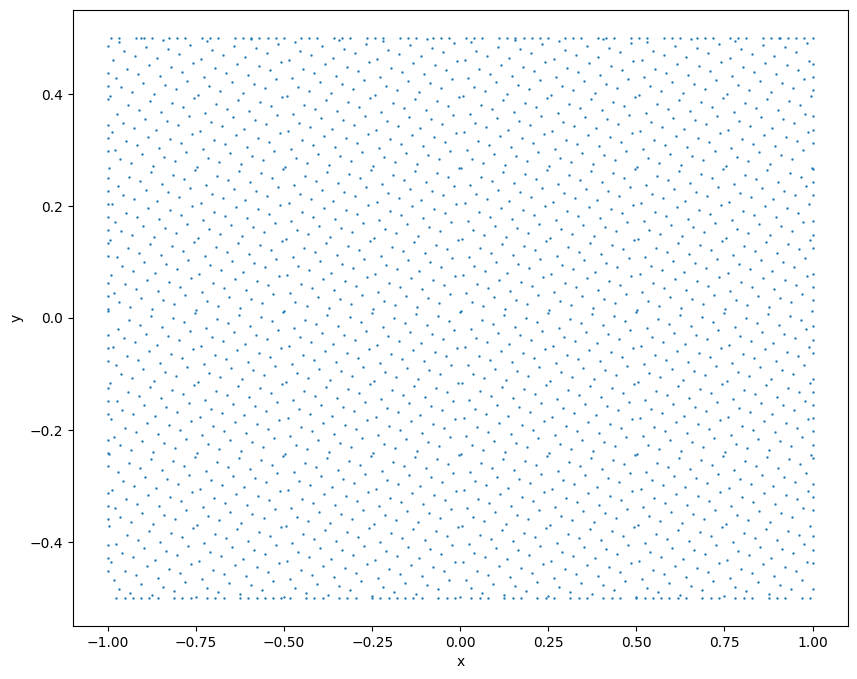

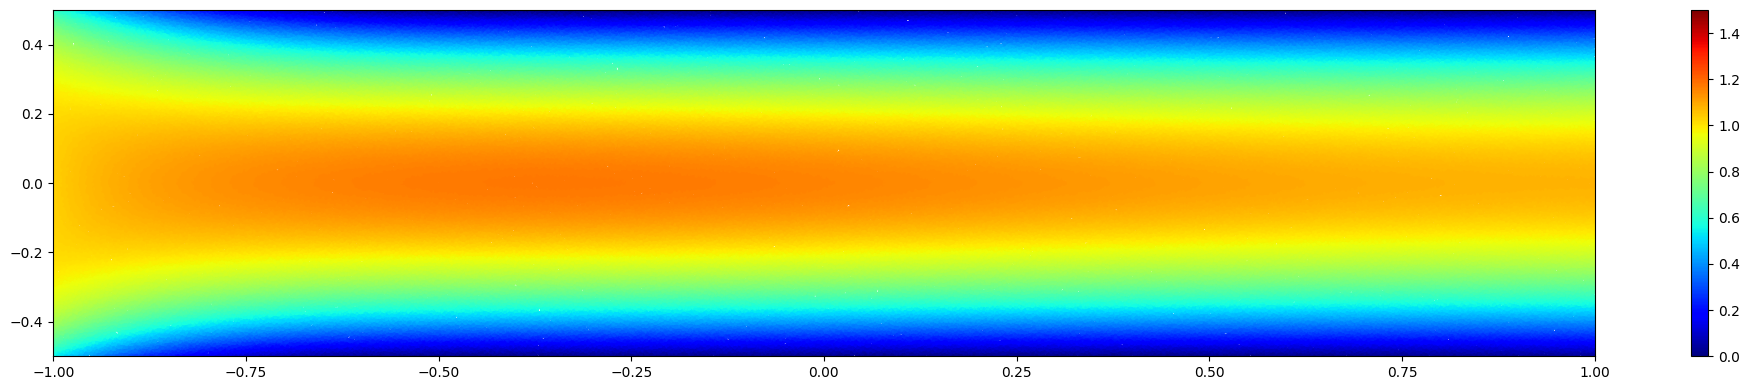

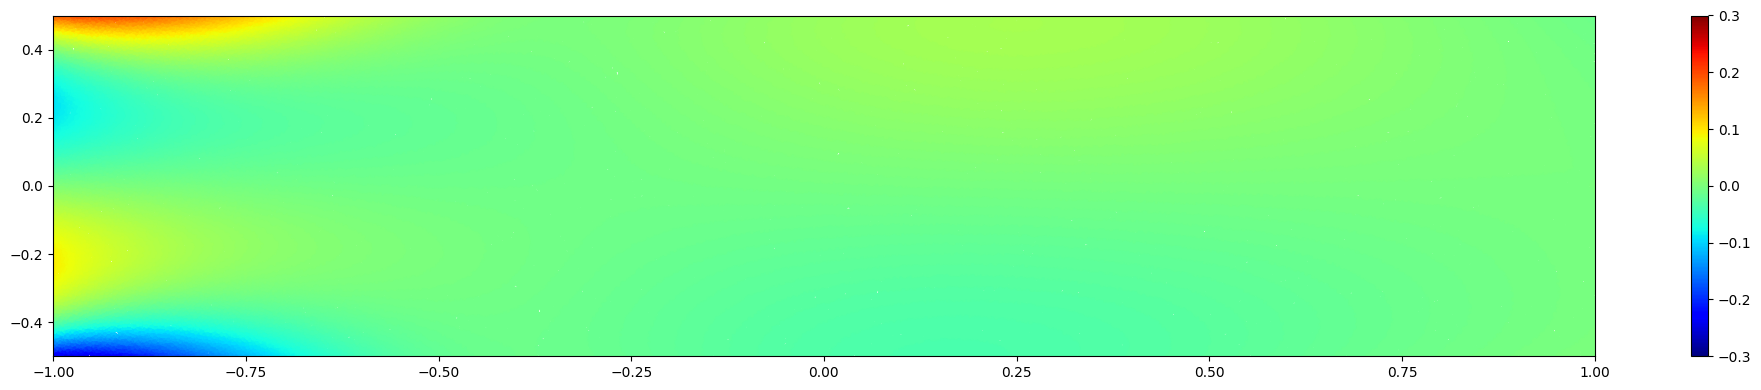

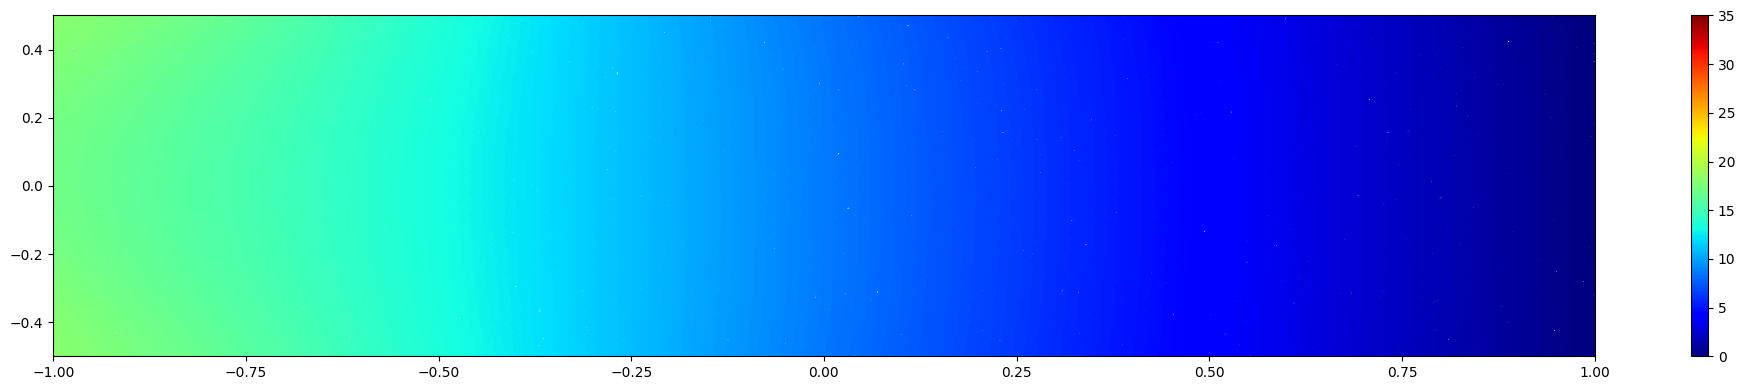

In [9]:
# Visualize training points
plt.figure(figsize=(10, 8))
plt.scatter(data.train_x_all[:, 0], data.train_x_all[:, 1], s=0.5)
plt.xlabel("x")
plt.ylabel("y")
plt.show()

# Predict and plot results
samples = geom.random_points(500000)
result = model.predict(samples)

color_legend = [[0, 1.5], [-0.3, 0.3], [0, 35]]
for idx in range(3):
    plt.figure(figsize=(20, 4))
    plt.scatter(samples[:, 0], samples[:, 1], c=result[:, idx], cmap="jet", s=2)
    plt.colorbar()
    plt.clim(color_legend[idx])
    plt.xlim((0 - L / 2, L - L / 2))
    plt.ylim((0 - D / 2, D - D / 2))
    plt.tight_layout()
    plt.show()

The three graphs respectively represents x-vel contour, y-vel contour and pressure contour